# 11. Live Tutorial 1: A Day in the Quality Lab — t-Tests in Practice

Notebook 8 (Hypothesis Testing) introduced each t-test in isolation. This
session puts them to work the way you actually will: as a sequence of real
decisions made over one working day by a materials-testing quality
engineer at an aluminium-casting supplier. Every dataset below is
synthetic but built to behave like real measurement data (realistic means,
realistic noise, occasional awkward non-normality) — the statistics and
the *decisions* they lead to are the point, not the specific numbers.

Each section pairs a short concept recap with a worked example and a
checkpoint exercise; "Going Further" sections (11.7–11.8) and the exercise
list at the end are substantial **self-study material**, beyond the core
session.

**Session plan**
1. 60-second recap: the hypothesis-testing framework
2. Incoming inspection: does this batch meet spec? (one-sample *t*)
3. Two suppliers, one decision: which is better? (two-sample *t*, Welch)
4. Effect size and confidence intervals: what the p-value doesn't tell you
5. Did the process change help? (paired *t*)
6. Porosity data won't cooperate (Mann–Whitney U)
7. *Going further*: bootstrap confidence intervals
8. *Going further*: planning tomorrow's sample size (power analysis)

## 11.1 The Framework, in 60 Seconds

Every test below follows the same five steps — internalise this checklist
once and every test in this notebook (and Notebook 8) is just "which
formula goes in step 3":

1. **State H0 and H1** in terms of the real quantity you care about (a
   population mean, a difference of means), not the sample you happened to
   collect.
2. **Check assumptions** relevant to the test (normality, equal variances,
   independence) — this determines *which* test you're even allowed to use.
3. **Compute the test statistic and p-value** — how surprising is your
   sample, if H0 were actually true?
4. **Compare to α** (your pre-agreed false-positive tolerance, almost
   always 0.05 in this course) and decide.
5. **Report an effect size and a confidence interval**, not just "p < 0.05"
   — Section 11.4 explains why step 5 is not optional in real reporting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
rng = np.random.default_rng(2024)

## 11.2 Incoming Inspection: One-Sample *t*-Test

A truck of A356-T6 aluminium castings just arrived from **Supplier A**.
Contract spec requires a mean ultimate tensile strength (UTS) of at least
**275 MPa**. You pull 18 castings for destructive testing.

- $H_0: \mu \geq 275$ MPa (the batch meets spec)
- $H_1: \mu < 275$ MPa (the batch is below spec)

This is a **one-sided** test — you only care about failure in one
direction (nobody rejects a batch for being *too* strong).

In [2]:
# ── Supplier A incoming batch ─────────────────────────────────────────────────
supplier_A = rng.normal(loc=279, scale=8, size=18).round(1)   # MPa
spec_min = 275

print('Supplier A UTS (MPa):', supplier_A)
print(f'Sample mean: {supplier_A.mean():.2f} MPa   Sample std: {supplier_A.std(ddof=1):.2f} MPa')

# Assumption check: is 18 samples roughly normal? Shapiro-Wilk + Q-Q
stat, p_shapiro = stats.shapiro(supplier_A)
print(f'\nShapiro-Wilk normality check: W={stat:.3f}, p={p_shapiro:.3f} '
      f'({"consistent with normal" if p_shapiro > 0.05 else "departs from normal"})')

Supplier A UTS (MPa): [287.2 292.1 288.2 271.2 267.9 279.5 285.9 283.1 293.5 285.  284.1 273.1
 270.1 290.9 279.4 285.5 268.  275.5]
Sample mean: 281.12 MPa   Sample std: 8.38 MPa

Shapiro-Wilk normality check: W=0.933, p=0.218 (consistent with normal)


In [3]:
# ── One-sided one-sample t-test ───────────────────────────────────────────────
t_stat, p_two_sided = stats.ttest_1samp(supplier_A, popmean=spec_min)
# ttest_1samp always returns the two-sided p-value; halve it for one-sided
# H1: mu < spec_min (and only trust the halved value if t_stat points that way,
# i.e. the sample mean fell below spec_min, making t_stat negative)
p_one_sided = p_two_sided / 2 if t_stat < 0 else 1 - p_two_sided / 2

print(f't-statistic: {t_stat:.3f}')
print(f'One-sided p-value (H1: mu < {spec_min}): {p_one_sided:.4f}')

alpha = 0.05
decision = 'ACCEPT batch' if p_one_sided > alpha else 'REJECT batch'
print(f'\nDecision at alpha={alpha}: {decision} '
      f'(sample mean {supplier_A.mean():.1f} MPa vs spec {spec_min} MPa)')

t-statistic: 3.098
One-sided p-value (H1: mu < 275): 0.9967

Decision at alpha=0.05: ACCEPT batch (sample mean 281.1 MPa vs spec 275 MPa)


**Checkpoint**: the p-value is large — we have *no evidence* the batch is
below spec. Note carefully what that does and does not mean: it does
**not** prove $\mu \geq 275$; it means the data are consistent with that
claim. Failing to reject H0 is never proof of H0 — a lesson worth
remembering every time you write up a QC report.

## 11.3 Two Suppliers, One Decision: Two-Sample *t*-Test

Procurement wants to know if switching to **Supplier B** (cheaper, new
contract) risks quality. You already have Supplier A's 18 measurements
from this morning; now test 15 castings from Supplier B.

Before comparing means, check the assumption every two-sample *t*-test
depends on: **do the two groups have equal variance?**

Supplier A: n=18, mean=281.1, std=8.4
Supplier B: n=15, mean=265.5, std=17.2


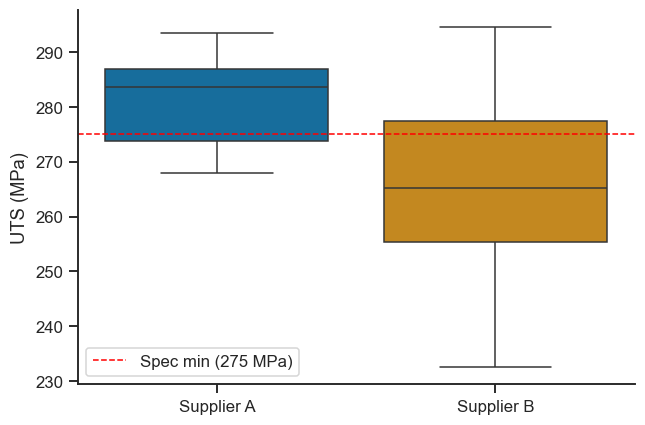

In [4]:
# ── Supplier B batch — similar mean, but a much less consistent process ──────
supplier_B = rng.normal(loc=271, scale=26, size=15).round(1)   # MPa

print(f'Supplier A: n={len(supplier_A)}, mean={supplier_A.mean():.1f}, std={supplier_A.std(ddof=1):.1f}')
print(f'Supplier B: n={len(supplier_B)}, mean={supplier_B.mean():.1f}, std={supplier_B.std(ddof=1):.1f}')

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=[supplier_A, supplier_B], ax=ax, palette='colorblind')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Supplier A', 'Supplier B'])
ax.set_ylabel('UTS (MPa)')
ax.axhline(spec_min, color='red', ls='--', lw=1, label=f'Spec min ({spec_min} MPa)')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [5]:
# ── Levene's test: are the variances equal? ───────────────────────────────────
levene_stat, levene_p = stats.levene(supplier_A, supplier_B)
print(f"Levene's test: F={levene_stat:.3f}, p={levene_p:.4f}")

equal_var = levene_p > 0.05
print(f'Equal variance assumption: {"holds" if equal_var else "VIOLATED"} at alpha=0.05')
print(f'-> use {"Student" if equal_var else "Welch"} t-test')

Levene's test: F=6.536, p=0.0157
Equal variance assumption: VIOLATED at alpha=0.05
-> use Welch t-test


Levene's test flags unequal variance here — Supplier B's process is
noticeably less consistent than Supplier A's (compare the two standard
deviations printed above), not just a coincidence of sampling. Using the
standard (pooled-variance) *t*-test anyway would
understate the true uncertainty in the comparison. **Welch's *t*-test**
fixes this by not assuming equal variances — it's implemented in
`scipy.stats.ttest_ind` via `equal_var=False`, and unlike the standard
test, its degrees of freedom are *not* simply $n_1+n_2-2$ (Welch–Satterthwaite
approximation instead) — one more reason to let the function compute it
rather than doing it by hand.

In [6]:
t_stat, p_val = stats.ttest_ind(supplier_A, supplier_B, equal_var=equal_var)
test_name = 'Student' if equal_var else 'Welch'

print(f'{test_name}\'s two-sample t-test:')
print(f'  t-statistic: {t_stat:.3f}')
print(f'  p-value (two-sided): {p_val:.4f}')
print(f'  Decision at alpha=0.05: '
      f'{"reject H0 -- means differ" if p_val < 0.05 else "fail to reject H0 -- no evidence of a difference"}')

Welch's two-sample t-test:
  t-statistic: 3.218
  p-value (two-sided): 0.0044
  Decision at alpha=0.05: reject H0 -- means differ


**Checkpoint / Exercise A**: Re-run Section 11.3 forcing `equal_var=True`
regardless of what Levene's test said. Does the conclusion change? This is
exactly the mistake Levene's test exists to catch — note it down as a
reason to *always* check the variance assumption before choosing which
flavour of *t*-test to run.

## 11.4 Effect Size and Confidence Intervals: What the p-Value Doesn't Tell You

A p-value answers *"is there evidence of a difference?"* — it says nothing
about **how big** that difference is, and a large sample can make a
practically meaningless difference statistically "significant." Two
numbers fix this, and a real QC report should always include them
alongside the p-value:

- **Cohen's *d*** — the difference in means, measured in units of pooled
  standard deviation: $d = (\bar{x}_1-\bar{x}_2)/s_{\text{pooled}}$. Rules
  of thumb: $|d|\approx0.2$ small, $0.5$ medium, $0.8$ large.
- **Confidence interval on the difference** — a range of plausible values
  for the true mean difference, which lets an engineer judge *practical*
  significance ("is a 5 MPa gap something we actually care about?") in a
  way a single p-value cannot.

In [7]:
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_std


d = cohens_d(supplier_A, supplier_B)
print(f"Cohen's d = {d:.2f}")

# 95% CI on the difference of means (Welch-adjusted, matching the test above)
diff = supplier_A.mean() - supplier_B.mean()
se_diff = np.sqrt(supplier_A.var(ddof=1)/len(supplier_A) + supplier_B.var(ddof=1)/len(supplier_B))
df_welch = (supplier_A.var(ddof=1)/len(supplier_A) + supplier_B.var(ddof=1)/len(supplier_B))**2 / (
    (supplier_A.var(ddof=1)/len(supplier_A))**2 / (len(supplier_A)-1) +
    (supplier_B.var(ddof=1)/len(supplier_B))**2 / (len(supplier_B)-1)
)
t_crit = stats.t.ppf(0.975, df_welch)
ci_low, ci_high = diff - t_crit*se_diff, diff + t_crit*se_diff

print(f'Mean difference (A - B): {diff:.1f} MPa')
print(f'95% CI on the difference: [{ci_low:.1f}, {ci_high:.1f}] MPa')
print(f'\nReport this as: "A exceeded B by {diff:.1f} MPa (95% CI [{ci_low:.1f}, {ci_high:.1f}]), '
      f'a {"large" if abs(d)>=0.8 else "medium" if abs(d)>=0.5 else "small"} effect (d={d:.2f}), '
      f'{"significant" if p_val<0.05 else "not significant"} at alpha=0.05."')

Cohen's d = 1.19
Mean difference (A - B): 15.7 MPa
95% CI on the difference: [5.5, 25.8] MPa

Report this as: "A exceeded B by 15.7 MPa (95% CI [5.5, 25.8]), a large effect (d=1.19), significant at alpha=0.05."


## 11.5 Did the Process Change Help? Paired *t*-Test

The plant floor supervisor extended the T6 artificial-ageing step by 30
minutes, hoping to raise strength. To isolate the effect of *just* the
process change (and not part-to-part variation in raw material), the
**same 15 casting moulds** are tested before and after — a **paired**
design. Pairing pays off when the two measurements on a unit are
*correlated* — here, each mould has its own baseline quality level that
carries over from "before" to "after," so subtracting removes that shared
baseline and isolates the treatment effect. (If the pairing variable were
unrelated to the outcome, pairing would only cost degrees of freedom
without any variance reduction to show for it — see the theory page's
t-test section for that caveat.) We'll prove the power gain for *this*
correlated case, not just assert it.

In [8]:
# ── Paired before/after measurements on the same 15 moulds ───────────────────
n_pairs = 15
mould_baseline_effect = rng.normal(0, 6, n_pairs)   # each mould's own "quality level"
before = 274 + mould_baseline_effect + rng.normal(0, 3, n_pairs)
after  = 274 + mould_baseline_effect + 6 + rng.normal(0, 3, n_pairs)   # true +6 MPa improvement

df_paired = pd.DataFrame({'mould_id': [f'M{i+1:02d}' for i in range(n_pairs)],
                           'before': before.round(1), 'after': after.round(1)})
df_paired['improvement'] = (df_paired['after'] - df_paired['before']).round(1)
print(df_paired)

   mould_id  before  after  improvement
0       M01   280.6  287.9          7.3
1       M02   271.2  274.7          3.5
2       M03   283.5  290.6          7.1
3       M04   270.8  275.2          4.4
4       M05   268.3  276.9          8.6
5       M06   285.3  288.5          3.2
6       M07   275.2  277.8          2.6
7       M08   273.8  275.2          1.4
8       M09   263.1  270.3          7.2
9       M10   261.2  273.3         12.1
10      M11   279.6  284.1          4.5
11      M12   266.4  274.6          8.2
12      M13   276.8  286.7          9.9
13      M14   282.8  294.3         11.5
14      M15   271.4  278.6          7.2


In [9]:
t_paired, p_paired = stats.ttest_rel(df_paired['after'], df_paired['before'])
print(f'Paired t-test:   t={t_paired:.3f}, p={p_paired:.5f}')

# Compare to (incorrectly) treating this as two independent samples
t_unpaired, p_unpaired = stats.ttest_ind(df_paired['after'], df_paired['before'])
print(f'Unpaired t-test: t={t_unpaired:.3f}, p={p_unpaired:.5f}   (same data, wrong analysis)')

print(f"\nMean improvement: {df_paired['improvement'].mean():.2f} MPa")
print('The paired test is more powerful here because it subtracts out each')
print("mould's own baseline quality level before testing -- exactly the")
print('between-mould variance that inflates the unpaired test\'s uncertainty.')

Paired t-test:   t=7.875, p=0.00000
Unpaired t-test: t=2.426, p=0.02194   (same data, wrong analysis)

Mean improvement: 6.58 MPa
The paired test is more powerful here because it subtracts out each
mould's own baseline quality level before testing -- exactly the
between-mould variance that inflates the unpaired test's uncertainty.


**Checkpoint / Exercise B**: Increase `mould_baseline_effect`'s standard
deviation in Section 11.5 from `6` to `20` (bigger part-to-part variability)
and re-run. What happens to the *gap* between the paired and unpaired
p-values as between-unit variability grows? This is exactly why paired /
blocked designs matter more the noisier your material system is — a
concept Part III, Notebook 9 §9.4 (two-way ANOVA) and this course's
Notebook 7 (Live Tutorial 2, Section 7.3) revisit as **blocking**.

## 11.6 Porosity Data Won't Cooperate: Mann–Whitney U

The day's last comparison: casting **porosity** (% void volume, from
CT scan) for two processes — gravity die casting vs. sand casting.
Porosity is bounded at zero and often right-skewed (most castings are
good, a long tail of worse ones) — exactly the kind of variable that
should make you suspicious of a *t*-test before you even plot it.

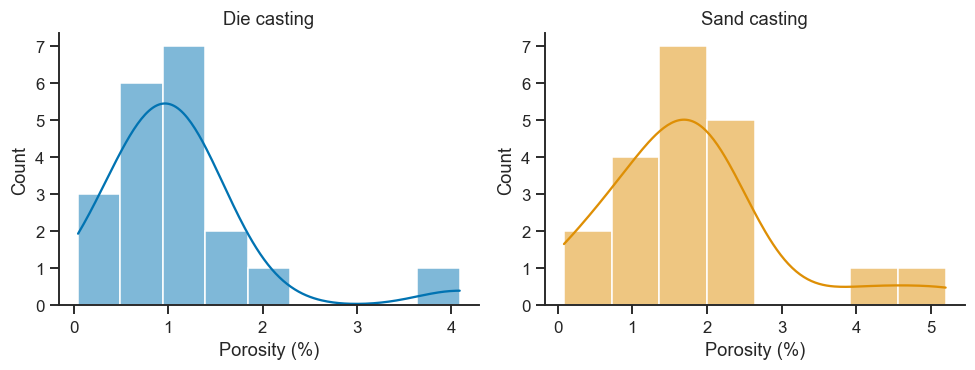

Die casting Shapiro-Wilk p = 0.0002 (NOT normal -- avoid the t-test)
Sand casting Shapiro-Wilk p = 0.0098 (NOT normal -- avoid the t-test)


In [10]:
# ── Porosity: right-skewed, simulated via a gamma distribution ────────────────
porosity_die  = rng.gamma(shape=2.0, scale=0.6, size=20)    # % porosity
porosity_sand = rng.gamma(shape=2.0, scale=0.9, size=20)    # sand casting: more porous

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
sns.histplot(porosity_die, kde=True, ax=axes[0], color=sns.color_palette('colorblind')[0])
axes[0].set_title('Die casting'); axes[0].set_xlabel('Porosity (%)')
sns.histplot(porosity_sand, kde=True, ax=axes[1], color=sns.color_palette('colorblind')[1])
axes[1].set_title('Sand casting'); axes[1].set_xlabel('Porosity (%)')
sns.despine()
plt.tight_layout()
plt.show()

for name, data in [('Die', porosity_die), ('Sand', porosity_sand)]:
    _, p_sw = stats.shapiro(data)
    print(f'{name} casting Shapiro-Wilk p = {p_sw:.4f} '
          f'({"normal-ish" if p_sw > 0.05 else "NOT normal -- avoid the t-test"})')

In [11]:
# ── Mann-Whitney U: compares *ranks*, not means -- valid without normality ────
u_stat, p_mw = stats.mannwhitneyu(porosity_die, porosity_sand, alternative='two-sided')
print(f'Mann-Whitney U = {u_stat:.1f}, p = {p_mw:.4f}')
print(f'Median porosity: die={np.median(porosity_die):.2f}%, sand={np.median(porosity_sand):.2f}%')
print(f'\nDecision at alpha=0.05: '
      f'{"processes differ significantly" if p_mw < 0.05 else "no significant difference detected"}')

Mann-Whitney U = 102.0, p = 0.0084
Median porosity: die=1.00%, sand=1.68%

Decision at alpha=0.05: processes differ significantly


:::{admonition} Take-home message
:class: tip

- Median porosity is 1.00% for die casting vs. 1.68% for sand casting — sand casting produces roughly 68% more void volume in a typical part, and p=0.008 says that gap is unlikely to be sampling noise.
- Because Mann-Whitney compares *ranks* rather than means, "sand casting tends to rank higher" is the precise claim being tested — not a difference in average porosity as such, though here both point the same direction.
:::

## 11.7 Going Further: Bootstrap Confidence Intervals

Every CI so far came from a *formula* that assumes a particular
distribution shape. The **bootstrap** sidesteps that assumption entirely:
resample your own data (with replacement) thousands of times, recompute
the statistic each time, and use the spread of those resampled statistics
directly as your confidence interval. It works for almost any statistic —
including the median, which has no simple textbook formula for a CI at
all — which is exactly why we apply it to the skewed porosity data below
rather than the well-behaved UTS data from earlier.

Sand casting median porosity: 1.68%
95% bootstrap CI on the median: [1.35, 2.02]%  (from 10,000 resamples)


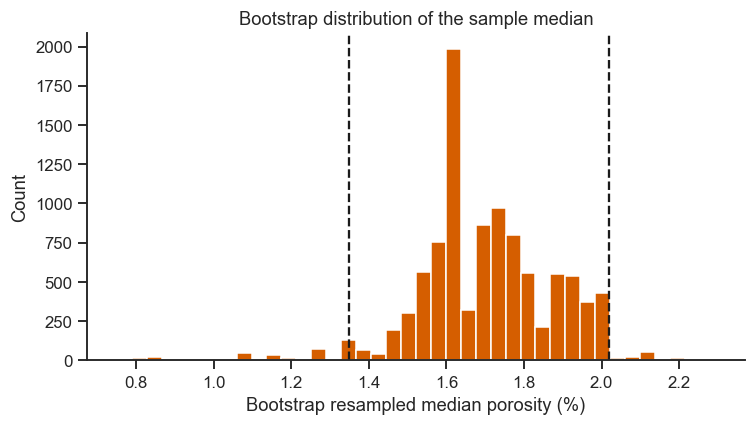

In [12]:
def bootstrap_ci(data, stat_func=np.median, n_boot=10_000, ci=0.95, seed=0):
    """Percentile-method bootstrap CI for any statistic (mean, median, ...)."""
    boot_rng = np.random.default_rng(seed)
    n = len(data)
    boot_stats = np.empty(n_boot)
    for i in range(n_boot):
        resample = boot_rng.choice(data, size=n, replace=True)
        boot_stats[i] = stat_func(resample)
    lo, hi = np.percentile(boot_stats, [(1-ci)/2*100, (1+ci)/2*100])
    return lo, hi, boot_stats


lo, hi, boot_medians = bootstrap_ci(porosity_sand, stat_func=np.median)
print(f'Sand casting median porosity: {np.median(porosity_sand):.2f}%')
print(f'95% bootstrap CI on the median: [{lo:.2f}, {hi:.2f}]%  (from {len(boot_medians):,} resamples)')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(boot_medians, bins=40, color=sns.color_palette('colorblind')[3], edgecolor='white')
ax.axvline(lo, color='k', ls='--'); ax.axvline(hi, color='k', ls='--')
ax.set_xlabel('Bootstrap resampled median porosity (%)')
ax.set_ylabel('Count')
ax.set_title('Bootstrap distribution of the sample median')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

:::{admonition} Take-home message
:class: tip

- The bootstrap CI [1.35, 2.02]% is centred near the reported median (1.68%), as expected — the *width* of the histogram above, not any textbook formula, is what generated this interval.
- Read it as: a follow-up batch's median porosity landing anywhere in [1.35, 2.02]% would not be surprising, given the scatter already present in this one 20-part sample.
:::

## 11.8 Going Further: Planning Tomorrow's Sample Size

Procurement wants stronger evidence on the Supplier A vs. B question
before signing a new contract. Given today's estimated effect size, how
many castings per supplier would tomorrow's test need to reliably detect
it? This is exactly Notebook 8 §8.5's power-analysis idea, applied here to
plan a **real follow-up experiment** from today's pilot data — the
realistic way sample-size planning actually happens.

In [13]:
from statsmodels.stats.power import TTestIndPower

analysis = TTestIndPower()
d_observed = abs(cohens_d(supplier_A, supplier_B))

for power_target in (0.80, 0.90, 0.95):
    n_needed = analysis.solve_power(effect_size=d_observed, alpha=0.05,
                                     power=power_target, ratio=1.0)
    print(f'Power={power_target:.0%}: need n={np.ceil(n_needed):.0f} per supplier '
          f'(observed d={d_observed:.2f})')

print(f'\nToday\'s pilot used n={len(supplier_A)} and n={len(supplier_B)} --',
      'compare that to the numbers above and judge whether today\'s test was adequately powered.')

Power=80%: need n=13 per supplier (observed d=1.19)
Power=90%: need n=16 per supplier (observed d=1.19)
Power=95%: need n=20 per supplier (observed d=1.19)

Today's pilot used n=18 and n=15 -- compare that to the numbers above and judge whether today's test was adequately powered.


:::{admonition} Take-home message
:class: tip

- Today's pilot used n=18 (Supplier A) and n=15 (Supplier B) — comfortably above the n=13 needed for 80% power, and close to (but just short of) the n=16 needed for 90% power. By the conventional 80% standard, today's test was adequately powered; by a stricter 90–95% standard some contracts might require, it was slightly under.
- These required-n numbers are only as good as the effect size they're based on (today's observed d=1.19) — if the true difference is smaller than this pilot happened to show, tomorrow's test would need more castings than planned here to keep the same power.
:::

---
## Exercises

**Core practice**

1. **One-sided vs two-sided**: Section 11.2 used a one-sided test because
   only low strength matters. Re-run it as a two-sided test
   (`stats.ttest_1samp` gives the two-sided p-value directly) and compare
   the p-value to the one-sided value computed manually. Which is larger,
   and can you explain why from the shape of the t-distribution?

2. **A third supplier**: Generate `supplier_C = rng.normal(285, 10, 20)`.
   Run the full Section 11.3–11.4 workflow (Levene → correct *t*-test →
   Cohen's *d* → CI) comparing Supplier A vs. Supplier C. Would you
   recommend switching from A to C?

3. **Wilcoxon signed-rank**: Section 11.5 assumed the paired *differences*
   are roughly normal (a *t*-test assumption you did not explicitly check).
   Run `stats.shapiro` on `df_paired['improvement']`, and if you were
   unconvinced it was normal, redo the test with
   `stats.wilcoxon(df_paired['after'], df_paired['before'])` — the paired
   analogue of Mann–Whitney U. Compare the p-values.

**Deeper practice**

4. **Type I and Type II error, simulated**: Write a loop that runs 1,000
   two-sample *t*-tests on data where you *know* H0 is exactly true (both
   groups drawn from the identical distribution, e.g.
   `rng.normal(275, 10, 15)` for both). What fraction reject H0 at
   alpha=0.05? It should be close to 5% — this *is* the definition of
   alpha, demonstrated empirically rather than asserted. Then repeat with a
   *true* difference of 5 MPa between groups and report the fraction that
   correctly reject H0 (this fraction is the test's empirical **power**).

5. **Bootstrap the mean, not just the median**: Apply `bootstrap_ci` from
   Section 11.7 to `supplier_A` with `stat_func=np.mean`, and compare the
   resulting interval to the classical *t*-interval
   (`stats.t.interval(0.95, df=len(supplier_A)-1, loc=supplier_A.mean(),
   scale=stats.sem(supplier_A))`). They should be close — bootstrap and
   classical methods should largely agree when the classical assumptions
   actually hold, which is a useful sanity check to run in both directions.

6. **Multiple comparisons**: If you ran Exercises 1–3 *and* the original
   Sections 11.2–11.6, you have performed roughly seven hypothesis tests
   today. What is the probability that *at least one* falsely rejects a
   true H0, purely by chance, if each individually runs at alpha=0.05?
   (Hint: $P(\text{at least one false positive}) = 1-(1-\alpha)^k$ for $k$
   independent tests.) This is exactly the problem ANOVA's omnibus F-test
   is designed to avoid when comparing more than two groups at once —
   Notebook 7 (Live Tutorial 2) picks this up directly.

7. **Design your own QC scenario**: Pick a materials system from earlier
   in the course (steel hardness, battery capacity, ceramic density —
   Notebooks 6–10) and write a one-paragraph QC scenario of your own,
   modelled on this notebook's "day in the lab" structure. Generate
   synthetic data for it and carry out whichever *t*-test the scenario
   calls for, including the assumption checks and effect size/CI
   reporting from Section 11.4.